### Overview
* Goal: Analyze the convergence of Black-Scholes analytical price vs Monte Carlo simulated price.
* Convergence expectation: O(N^(-1/2))

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.insert(0, './../src')

In [3]:
from validations.convergence import run_call_convergence_experiment

In [4]:
metrics = run_call_convergence_experiment()

In [6]:
metrics[0]

{'n_paths': 1024,
 'bs_price': 9.227005508154036,
 'mc_price': 7.7165385994156095,
 'mc_std_error': 0.38742572469388425,
 'abs_error': 1.5104669087384268}

In [7]:
df = pd.DataFrame(metrics)

In [8]:
df

,n_paths,bs_price,mc_price,mc_std_error,abs_error
0,1024,9.227006,7.716539,0.387426,1.510467
1,2048,9.227006,8.586292,0.298797,0.640713
2,4096,9.227006,8.958397,0.214280,0.268608
3,8192,9.227006,8.915012,0.149708,0.311993
4,16384,9.227006,9.096193,0.107512,0.130813
5,32768,9.227006,9.112239,0.075866,0.114767
6,65536,9.227006,9.185842,0.053728,0.041164
7,131072,9.227006,9.210993,0.038132,0.016013
8,262144,9.227006,9.227134,0.026986,0.000128
9,524288,9.227006,9.228640,0.019107,0.001635


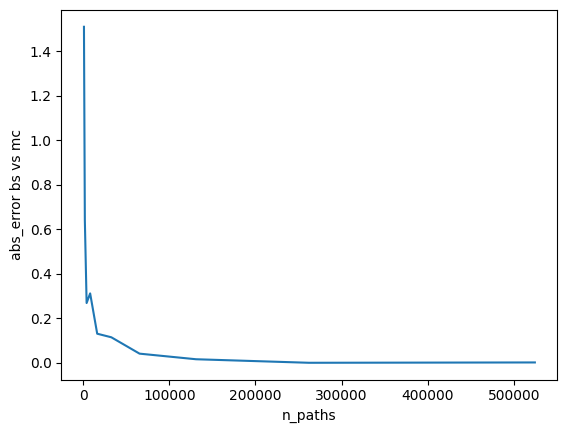

In [16]:
import numpy as np
plt.plot(df['n_paths'], df['abs_error'])
plt.xlabel('n_paths')
plt.ylabel('abs_error bs vs mc')
plt.show()

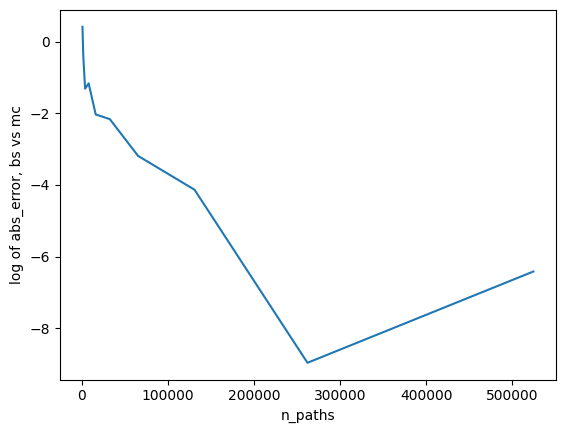

In [17]:
plt.plot(df['n_paths'], np.log(df['abs_error'])) # Expectation to see near straight line as abs error = O(1/sqrt(N))
plt.xlabel('n_paths')
plt.ylabel('log of abs_error, bs vs mc')
plt.show()

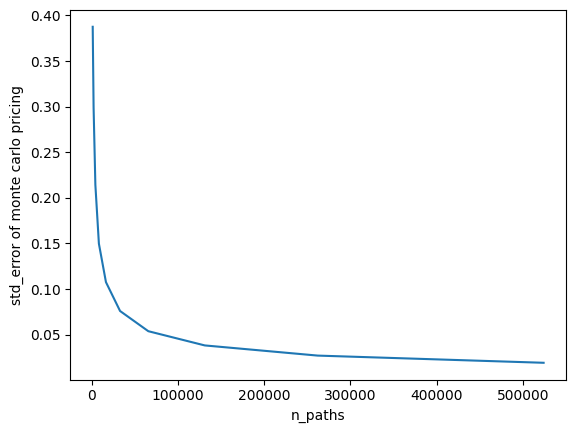

In [18]:
plt.plot(df['n_paths'], df['mc_std_error']) # Expectation to see near straight line as abs error = O(1/sqrt(N))
plt.xlabel('n_paths')
plt.ylabel('std_error of monte carlo pricing')
plt.show()